# Assignment 1: Data and Probability Foundations
Authored by Kristian M. P. Dashnaw (344849) & Katrine B. Aamand (344848) <br>
Based on assignment 1 description (https://rbrooksdk.github.io/STA1_26/assignments/assignment_01_data_and_probability_foundations/)

## Table of Contents

1. **Part 1 — Digital services**
    - a. Observational Unit, Variables, and Alert-Type Frequencies
    - b. Latency Summary Statistics — Overall and by Service
    - c. Latency Histogram and Service Boxplots
    - d. Outlier Identification with the 1.5 × IQR Rule
    - e. Descriptive Comparison of the Three Services
2. **Part 2 — Smart-Building Measurements**
    - a. Observational Unit, Variables, and Zone Summary Statistics
    - b. Indoor Temperature over Time by Zone
    - c. Outdoor Temperature against Energy Consumption
    - d. Conclusions on Temperature Stability and Zone Differences
3. **Part 3 — Cybersecurity alert system**
    - a. The Four Elementary Outcomes
    - b. Expected-Count Table for 100,000 Attempts
    - c. Probability Calculations and Table Verification
    - d. Direction of Conditioning, Independence, and Mutual Exclusivity
    - e. Effect of a Reduced False-Positive Rate
4. **Part 4 — AI Use and Conclusion**
    - a. AI Use
    - b. Conclusion

In [1]:
#Imports:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data files:
print("\nDigital_Services.csv, first 5 rows:")
digitalServicesData_unmodified = pd.read_csv('data/assignment01_digital_services.csv', delimiter = ',')
display(digitalServicesData_unmodified.head(5))

print("\n\nSmart_Building.csv, first 5 rows:")
smartBuildingData_unmodified = pd.read_csv('data/assignment01_smart_building.csv', delimiter = ',')
display(smartBuildingData_unmodified.head(5))


Digital_Services.csv, first 5 rows:


,observation_id,service,latency_ms,alert_type
0,1,orders,112.70,none
1,2,orders,109.83,none
2,3,telemetry,99.02,none
3,4,telemetry,94.44,none
4,5,telemetry,97.09,none




Smart_Building.csv, first 5 rows:


,measurement_id,hour,zone,outdoor_temp_c,indoor_temp_c,energy_kwh
0,1,1,north,2.14,21.02,41.31
1,2,2,north,1.37,19.99,39.36
2,3,3,north,1.35,20.39,43.58
3,4,4,north,1.59,19.98,45.55
4,5,5,north,2.30,20.74,41.09


<br><br><br><br><br>
## Part 1: Digital Services
The file ```assignment01_digital_services.csv``` contains latency measurements and security-alert categories for three digital services.

### a. Identify the observational unit, the relevant population, and each variable as categorical or quantitative. Create a frequency table for alert_type containing counts and percentages.

In [12]:
# Kristian

### Identifying the observational unit and relevant population
 **Observational unit   :**  A single row of observations, identifiable by its observation_id in the provided dataset

 **Population           :**  The complete set of all observational units that were made over the timeframe the observations were recorded digital services were recorded within. The provided data set is merely a sample of this population.

### Identifying the variables in the services data set:

|    Variable    | Data Type                            |                                                                                                          Reason                                                                                                          |
|:--------------:|:-------------------------------------|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------:|
| observation_id | Neither qualitative or quantitative. |                                                      These are just identifiers. They don't tell much more than the order in which the observations were recorded.                                                       |
|    service     | Categorical/Qualitative data.        | Because services is non-numerical information and it relate to a limited number of values identifying each service (i.e. orders, telemetry, etc) and can be used to categorize the observations within these categories. |
|   latency_ms   | Quantitative data                    |                                                        These are continuos measured values that can take any value from ~0ms to infinite ms. These are numerical.                                                        |
|   alert_type   | Categorical/Qualitative data         |        Similar to services, this is also non-numerical data that is limited to a number of values indicating the type of each alert, which thus makes it easy to categorize meaningfully according to alert type.        |

In [13]:
print("\n\033[1m The frequency table for alert_types: \033[0m")
alert_counts = digitalServicesData_unmodified["alert_type"].value_counts()

freqTable = pd.DataFrame({
    "Frequency (#)": alert_counts,
    "Relative Frequency (%)": alert_counts / alert_counts.sum() * 100
})

display(freqTable)


 The frequency table for alert_types: 


,Frequency (#),Relative Frequency (%)
alert_type,,
none,104,72.222222
authentication,25,17.361111
rate_limit,9,6.250000
injection_signature,6,4.166667


<br><br>
### b. For latency_ms, report the sample size, mean, median, sample standard deviation, minimum, (Q_1), (Q_3), maximum, and IQR:
- for all observations combined; and
- separately for each $service$.

In [14]:
# Kristian
print("\n\033[1m Key latency_ms stats: \033[0m")
# Let's build the stats. We use pandas built in .describe() function, since this gives all mandatory information except the IQR
# .describe() calculates count, mean, std, min. 25% quartile (Q_1), 75% quartile (Q_3), max.
overall_latency_stats = digitalServicesData_unmodified['latency_ms'].describe().to_frame('All observations').T
services_latency_stats = digitalServicesData_unmodified.groupby('service')['latency_ms'].describe()
all_latency_stats = pd.concat([overall_latency_stats, services_latency_stats])

all_latency_stats = all_latency_stats.rename(columns={
    "count": "sample_size",
    "50%":   "median",
    "25%":   "Q_1 (25%)",
    "75%":   "Q_3 (75%)",
})

# Compute the IQR
all_latency_stats['IQR'] = all_latency_stats['Q_3 (75%)'] - all_latency_stats['Q_1 (25%)']

# Ensure that the standard deviation uses the n-1 divisor (instead of n, which is standard in numpy), since we are working with samples (such as for the services)
# ddof (delta degress of freedom) is the value that determines what we are subtracting from the n value, during std computations.
population_std = pd.concat([
    pd.Series({'All observations': np.std(digitalServicesData_unmodified['latency_ms'], ddof=0)}),
    digitalServicesData_unmodified.groupby('service')['latency_ms'].agg(lambda s: np.std(s, ddof=0))
])

# Prettify the table naming:
column_order = ['sample_size', 'mean', 'median', 'std', 'min', 'Q_1 (25%)', 'Q_3 (75%)', 'max',  'IQR']
all_latency_stats = all_latency_stats[column_order]

display(all_latency_stats.round(3))

print("\n\033[1mPopulation std (ddof=0), for comparison with sample std (ddof=1, default in pandas):\033[0m")
print(population_std.round(3).to_string())

print("\nLegend:")
print("mean/average : The central tendency of the dataset. Is the sum of all values divided by the number of values.")
print("median       : The middle value of a sorted dataset.")
print("std          : The Standard Deviation. Measures how spread out the data is from the mean. High value = high spread. Low value = close to mean.")
print("min          : The smallest value of a sorted dataset.")
print("max          : The largest value of a sorted dataset.")
print("25%          : The Median of the lower half of the dataset.")
print("50%          : The Median of the entire dataset.")
print("75%          : The Median of the upper half of the dataset.")
print("IQR          : The spread of the middle 50% of the data (Q3 - Q1). Indicates how clustered or spread the central portion of the data set is\n")



 Key latency_ms stats: 


,sample_size,mean,median,std,min,Q_1 (25%),Q_3 (75%),max,IQR
All observations,144.0,110.111,106.930,23.099,75.21,95.845,116.885,223.80,21.04
identity,49.0,96.068,93.720,16.121,75.21,85.390,105.100,154.27,19.71
orders,50.0,122.200,114.525,24.813,98.53,109.838,124.148,223.80,14.31
telemetry,45.0,111.971,106.920,19.385,86.78,97.950,116.830,177.87,18.88



Population std (ddof=0), for comparison with sample std (ddof=1, default in pandas):
All observations    23.019
identity            15.956
orders              24.563
telemetry           19.168

Legend:
mean/average : The central tendency of the dataset. Is the sum of all values divided by the number of values.
median       : The middle value of a sorted dataset.
std          : The Standard Deviation. Measures how spread out the data is from the mean. High value = high spread. Low value = close to mean.
min          : The smallest value of a sorted dataset.
max          : The largest value of a sorted dataset.
25%          : The Median of the lower half of the dataset.
50%          : The Median of the entire dataset.
75%          : The Median of the upper half of the dataset.
IQR          : The spread of the middle 50% of the data (Q3 - Q1). Indicates how clustered or spread the central portion of the data set is



<br><br>
### c. Create a histogram of all latency measurements and side-by-side boxplots for the three services. Explain the histogram's axes, bins, and displayed shape and the boxplot's median, box, whiskers, and plotted potential outliers.


 Frequency table showing the binned latencies: 


,frequency,relative (%),cumulative
latency_ms,,,
"(75.0, 90.0]",22,15.3,22
"(90.0, 105.0]",42,29.2,64
"(105.0, 120.0]",52,36.1,116
"(120.0, 135.0]",11,7.6,127
"(135.0, 150.0]",10,6.9,137
"(150.0, 165.0]",3,2.1,140
"(165.0, 180.0]",2,1.4,142
"(180.0, 195.0]",0,0.0,142
"(195.0, 210.0]",0,0.0,142


This confirms that all 144 observational units were parsed into the bins, and that the binned range (10 x 15ms from 75ms) encapsulates all the observational units



 Histogram: 


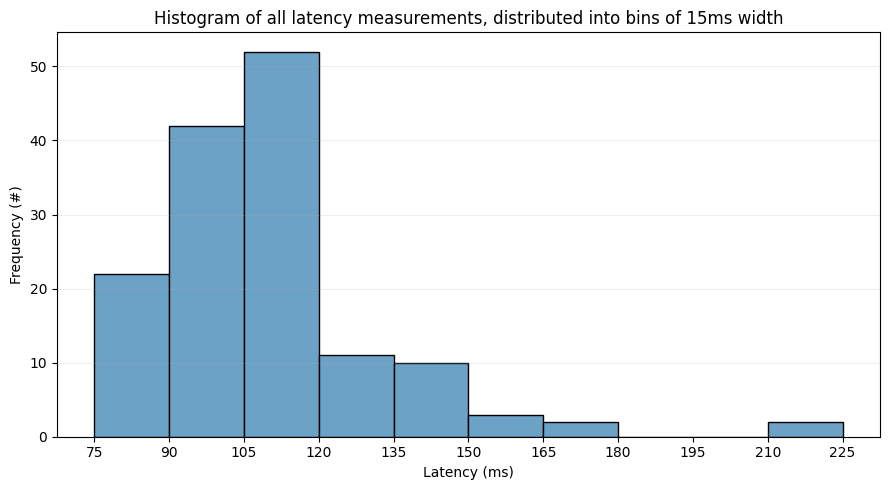

In [15]:
# Kristian
# A histogram is defined as a bar graph that plots the frequencies of data grouped into bins.
# We will display an absolute frequency histogram, where the vertical axis will denote the absolute frequency of recorded latencies.
latencies = digitalServicesData_unmodified['latency_ms'].copy()

# Since the min value of latencies is 75.21ms and max is 223.8ms, that gives a spread between min-max of ~148ms between min & max.
# I will thus use 10 bins, each with a size of 15ms (total 150ms).
edges = np.arange(75, latencies.max() + 15, 15)
binned = pd.cut(latencies, bins=edges)

counts = binned.value_counts().sort_index()
freq_table = pd.DataFrame({
    'frequency':    counts,
    'relative (%)': (counts / counts.sum() * 100).round(1),
    'cumulative':   counts.cumsum(),
})

print("\n\033[1m Frequency table showing the binned latencies: \033[0m")
display(freq_table)
print("This confirms that all 144 observational units were parsed into the bins, and that the binned range (10 x 15ms from 75ms) encapsulates all the observational units\n\n")

print("\n\033[1m Histogram: \033[0m")
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(latencies, bins=edges, edgecolor="black", color="#6CA2C6")

ax.set_xticks(edges)
ax.set_xlabel("Latency (ms)")
ax.set_ylabel("Frequency (#)")
ax.set_title("Histogram of all latency measurements, distributed into bins of 15ms width")
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()


### Histogram explanation:
**A histogram is a bar graph that plots the frequencies of data by grouping these into bins.**<br>
**The x-axis:** Shows the distribution of the bins. In this case we are using 10 bins, each with a width of 15ms.<br>
**The y-axis:** Shows how many counts of each data (latency_ms) are present inside each bin.<br>
**Shape:** The histogram shows as a **right skewed** (positively skewed). This can be seen by the tail of the distribution being on the right side. Another indicator is the median (ca. 106ms) is smaller than the mean (ca. 110ms), as shown in 1b.



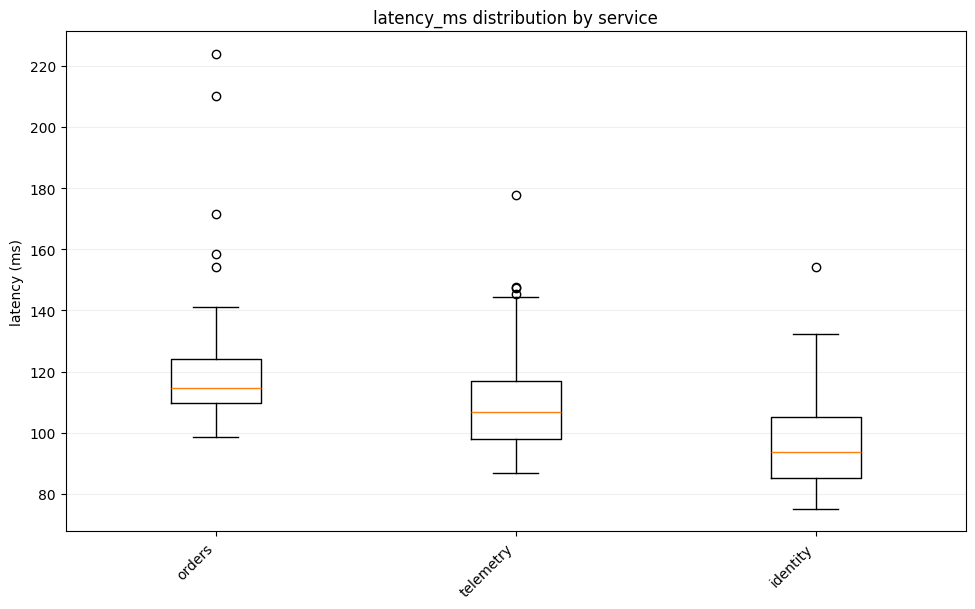

In [16]:
# Iterate through the data set, extracting latency pr. service into each set
dataSets = dict()
for row in digitalServicesData_unmodified.itertuples():
    if row.service in dataSets:
        dataSets[row.service].append(row.latency_ms)
    else:
        dataSets.update({row.service: [row.latency_ms]})

# Plot the boxplot
data = []
ticks = []
x_axis_names = []

for key in dataSets:
    data.append(dataSets.get(key))
    if key not in x_axis_names:
        x_axis_names.append(key)
        ticks.append(len(ticks))

fig = plt.figure(figsize=(9, 5))
ax = fig.add_axes([0, 0, 1, 1])

bp = ax.boxplot(data, showfliers=True)
ax.set_xticklabels(x_axis_names, rotation=45, ha="right")

ax.set_ylabel('latency (ms)')
ax.set_title('latency_ms distribution by service')
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)

plt.show()

### Boxplot explanation:
**A boxplot provides a compact summary of data distribution in a data set**<br>
**Boxplot Median:** The center line within the 'box' shown in all 3 box plots represents the median of the dataset. For 'orders' it's ca. 115ms. For 'telemetry' it's ca. 110ms and for 'identity' it's ca. 90ms.<br>
**Boxplot box:** The box on each plot shows the interquartile range between Q1 and Q3. I.e. the lower line of each box is the Q1 value while the upper is the Q3 value. This, as an effect, contains 50% of the data set.<br>
**Whiskers:** These reference the max and minimum values in the dataset, excluding outliers.<br>
**Outliers:** These are shown as dots in the shown box plots. Box plots can be drawn with or without these outliers. Outliers are defined as values that fall beneath the lower fence, or above the upper fence (which also bounds the values the whiskers of each box can be). Outliers below the main data set are defined as being smaller than ```Q1 - 1.5 * IQR```, while the outliers that lie above the main data set are defined as larger than ```Q3 + 1.5 * IQR```.

<br><br>
### d. Apply the $1.5 \times \mathrm{IQR}$ rule within each service. Report the IDs and values of potential outliers, retain them in the analysis, and explain why a plotted outlier is not automatically a data error.

In [17]:
# Kristian
# All latency stats were computed in 1b. We will re-use those computed stats here:

# Isolate the IQRs for each service
orders_service_IQR = all_latency_stats.loc['orders', 'IQR']
orders_service_Q1 = all_latency_stats.loc['orders', 'Q_1 (25%)']
orders_service_Q3 = all_latency_stats.loc['orders', 'Q_3 (75%)']

telemetry_service_IQR = all_latency_stats.loc['telemetry', 'IQR']
telemetry_service_Q1 = all_latency_stats.loc['telemetry', 'Q_1 (25%)']
telemetry_service_Q3 = all_latency_stats.loc['telemetry', 'Q_3 (75%)']

identity_service_IQR = all_latency_stats.loc['identity', 'IQR']
identity_service_Q1 = all_latency_stats.loc['identity', 'Q_1 (25%)']
identity_service_Q3 = all_latency_stats.loc['identity', 'Q_3 (75%)']

print(f"Extracted Q1 values : ordersQ1={orders_service_Q1.round(3)},  telemetryQ1={telemetry_service_Q1.round(3)},  identityQ1={identity_service_Q1.round(3)}")
print(f"Extracted Q3 values : ordersQ3={orders_service_Q3.round(3)},  telemetryQ3={telemetry_service_Q3.round(3)}, identityQ3={identity_service_Q3.round(3)}")
print(f"Extracted IQR values: ordersIQR={orders_service_IQR.round(3)},   telemetryIQR={telemetry_service_IQR.round(3)}, identityIQR={identity_service_IQR.round(3)}")

# Iterate through all digital services data entries and flag any outliers, according to the IQR that applies for each service.
# IQR Rule: Lower fence: Q1 - 1.5 x IQR                 Upper fence: Q3 + 1.5 x IQR
digitalServicesData_withOutliersFlagged = digitalServicesData_unmodified.copy().assign(is_outlier=False)
for index, row in digitalServicesData_withOutliersFlagged.iterrows():
    if row['service'] == 'orders':
        digitalServicesData_withOutliersFlagged.at[index, 'is_outlier'] = (
                row['latency_ms'] < (orders_service_Q1 - 1.5 * orders_service_IQR) or
                row['latency_ms'] > (orders_service_Q3 + 1.5 * orders_service_IQR)
        )
    elif row['service'] == 'telemetry':
                digitalServicesData_withOutliersFlagged.at[index, 'is_outlier'] = (
                row['latency_ms'] < (telemetry_service_Q1 - 1.5 * telemetry_service_IQR) or
                row['latency_ms'] > (telemetry_service_Q3 + 1.5 * telemetry_service_IQR)
        )
    elif row['service'] == 'identity':
        digitalServicesData_withOutliersFlagged.at[index, 'is_outlier'] = (
        row['latency_ms'] < (identity_service_Q1 - 1.5 * identity_service_IQR) or
        row['latency_ms'] > (identity_service_Q3 + 1.5 * identity_service_IQR)
        )

print("\n\033[1m Identified outliers in the dataset, according to the IQR Rule applied for each service: \033[0m")
display(digitalServicesData_withOutliersFlagged[digitalServicesData_withOutliersFlagged['is_outlier']])

Extracted Q1 values : ordersQ1=109.838,  telemetryQ1=97.95,  identityQ1=85.39
Extracted Q3 values : ordersQ3=124.148,  telemetryQ3=116.83, identityQ3=105.1
Extracted IQR values: ordersIQR=14.31,   telemetryIQR=18.88, identityIQR=19.71

 Identified outliers in the dataset, according to the IQR Rule applied for each service: 


,observation_id,service,latency_ms,alert_type,is_outlier
18,19,orders,210.10,none,True
32,33,telemetry,147.26,authentication,True
38,39,telemetry,145.52,none,True
59,60,orders,171.59,rate_limit,True
65,66,orders,158.59,none,True
86,87,orders,154.32,authentication,True
87,88,orders,223.80,injection_signature,True
119,120,telemetry,147.79,none,True
131,132,identity,154.27,none,True
132,133,telemetry,177.87,none,True


### Outlier report:
10 outliers were identified in the dataset, when the IQR rule was applied onto each service using the IQR specific for each service.<br>
These are shown in the table above.<br> 4 outliers exist on telemetry. 5 outliers on orders. 1 outlier on identity. These findings correspond with the outliers identified and plotted in 1c.<br>
No outliers were identified below the min. value included in the previous box-plots. The value of the smallest outlier (observation_id=39) has a latency of 145.52ms and relate to the telemetry service. The largest outlier (observation_id=88) has a latency of 223.8ms and relates to the orders service.<br>
The upper fence for outliers on the telemetry service is 116.83ms + 1.5 * 18.88ms = 145.15ms<br>

#### Why are outliers not automatically data errors?
In this case, the outliers represent actually measured latencies. None of the recorded values are infinitely large, negative, or otherwise illegal values that would indicate errors in the data.<br>
The 1.5 x IQR rule does not measure correctness of the data that it defines as outliers. It merely points them out. Whether they are valid data points or not, is entirely up to me as a data analyst to determine.<br>
Blindly removing all outliers, without assessing the validity of each outlier, would skew the data as this removal would significantly adjust the various statistics for each service.<br>

The specific effects of removing outliers for each service is shown on the table below:

In [18]:
digitalServicesData_withOutliersRemoved = digitalServicesData_withOutliersFlagged[-digitalServicesData_withOutliersFlagged['is_outlier']].copy()

overall_latency_stats_no_outliers = digitalServicesData_withOutliersRemoved['latency_ms'].describe().to_frame('All observations (no outliers)').T
services_latency_stats_no_outliers = digitalServicesData_withOutliersRemoved.groupby('service')['latency_ms'].describe()
all_latency_stats_no_outliers = pd.concat([overall_latency_stats_no_outliers, services_latency_stats_no_outliers])

all_latency_stats_no_outliers = all_latency_stats_no_outliers.rename(columns={
    "count": "sample_size",
    "50%":   "median",
    "25%":   "Q_1 (25%)",
    "75%":   "Q_3 (75%)",
})

all_latency_stats_no_outliers = all_latency_stats_no_outliers.rename(index={
    "identity": "identity (no outliers)",
    "orders":   "orders (no outliers)",
    "telemetry":   "telemetry (no outliers)"
})

# Compute the IQR
all_latency_stats_no_outliers['IQR'] = all_latency_stats_no_outliers['Q_3 (75%)'] - all_latency_stats_no_outliers['Q_1 (25%)']

# Prettify the table naming:
column_order = ['sample_size', 'mean', 'median', 'std', 'min', 'Q_1 (25%)', 'Q_3 (75%)', 'max',  'IQR']
all_latency_stats_no_outliers = all_latency_stats_no_outliers[column_order]

all_latency_stats_expanded = pd.concat([all_latency_stats, all_latency_stats_no_outliers])

print("\n\033[1m Key statistics on latency, with and without outliers: \033[0m")
display(all_latency_stats_expanded.round(3))


 Key statistics on latency, with and without outliers: 


,sample_size,mean,median,std,min,Q_1 (25%),Q_3 (75%),max,IQR
All observations,144.0,110.111,106.930,23.099,75.21,95.845,116.885,223.80,21.040
identity,49.0,96.068,93.720,16.121,75.21,85.390,105.100,154.27,19.710
orders,50.0,122.200,114.525,24.813,98.53,109.838,124.148,223.80,14.310
telemetry,45.0,111.971,106.920,19.385,86.78,97.950,116.830,177.87,18.880
All observations (no outliers),134.0,105.708,105.875,15.536,75.21,95.040,114.528,144.27,19.488
identity (no outliers),48.0,94.855,93.425,13.851,75.21,84.632,104.192,132.26,19.560
orders (no outliers),45.0,115.369,113.590,10.895,98.53,109.520,119.380,141.15,9.860
telemetry (no outliers),41.0,107.811,105.310,13.989,86.78,97.870,114.190,144.27,16.320


Comparing the key statistics above, we see that removing the outliers generally heavily affects the mean values, IQR and std. The mean for all observations drops from ca. 110ms to 105ms, while the median for all observations only drops from 106ms to 105ms. The outlier removal thus affects the median significantly less, then the mean. Similarly we see the standard deviation (n-1 based) drop from 23ms to 15ms, another significant drop.

The orders service is especially affected adversely from the outlier removal. Its mean drops from 122ms to 115ms, with its median only dropping 1ms (from 114ms to 113ms). Its IQR however drops significantly, from 14ms to ca. 10ms, indicating the data has become tighter and more close to each other (i.e. more data fits within a smaller quartile range).



<br><br>
### e. Write a short descriptive comparison of the services. Comment on typical latency, spread, skewness, the relationship between mean and median, and what cannot be generalised from these descriptive differences alone.

```
#Kristian
```

Statistics relating to 3 services were produced in this part 1. The 'orders', 'telemetry' and 'identity' digital services. Each service associated with recorded latencies (ms) and alerts.

**The orders service** featured the highest typical latency of 114.5ms (median) with an average latency of 122ms (mean). The median is the more appropriate measure here, since 5 outliers above the upper fence were identified, the maximum value of the outlier reaching 223.8ms, while the upper value (without outliers) sits at 141.15ms. As such, the mean for 'orders' is skewed upward, while the median sits closer to what can typically be expected from the orders service based on the provided sample. The order service has the smallest interquartile range (IQR) of the 3 services, sitting at 14.3ms. This indicates that the middle 50% of the orders recorded observations sit within a spread of 14.3ms from each other. While the order service has the largest standard deviation (std) with the 5 outliers (24.8ms), this changes completely when outliers are removed and the std drops to 10.895ms (ca. 14ms drop). This also shows that standard deviation is more sensitive to outliers than the IQR which dropped from 14.3ms to 9.8ms when outliers were removed.

**The telemetry service** lies in the middle between the other 2 services in regard to latency. With a median latency of 106.9ms and a mean latency of 111.9ms it sits below the orders service, and above the identity service. 4 outliers were identified, of which 3 sit very close to the upper fence (see boxplot in 1c). With an IQR of 18.8ms it sits higher than the orders service and close to the identity services IQR of 19.7. This indicates a larger spread between the core observations that make up 50% of the telemetry data. Its standard deviation (19.3ms) also sits comfortably between the orders service (24.8ms) and the identity service (16.1ms).

**The identity service** appears to be the fastest responding service of the 3. Its median latency sits at 93.7ms with a mean at 96ms. Only 1 outlier was identified in this service, skewing the mean latency slightly upwards. This service has the highest IQR (19.7ms), but the smallest standard deviation between observations (16.1ms) as measured indicating that while the quartile range that makes up the middle 50% of the data is larger than in the other services, the spread between observations is also the smallest. But this is only due to having a single outlier. As seen in 1d, if outliers are removed, std also falls in the other services due to no longer being skewed as significantly due to these upper outliers.

All 3 services are right skewed, with consistent median having smaller values than their corresponding means. The orders service is skewed 7.7ms to the right. The telemetry service 5.05ms to the right and the identity service 2.3ms. This indicates that the identity service is the least skewed.

**Disclaimer:** These descriptive comparisons, as well as the provided statistics, can not be used to determine causality. They only show what was recorded within the timeframe that the sample observational units were recorded, but tell nothing of why or how this data came to be. Additionally, since the sampling method (or the method of data collection) were not described it is not possible to conclude whether each system was operating in its normal capacity, or whether any of these systems were already in an abnormal state when observations began.


<br><br><br><br><br>
## Part 2: Smart-building measurements
The file ```assignment01_smart_building.csv``` contains two days of hourly measurements from the north and south zones of a smart building.

#### a. Identify the observational unit and variables. For `indoor_temp_c` and `energy_kwh`, report $n$, mean, median, and sample standard deviation separately for each zone.

` #Katrine`

An observational unit is a single hourly measurement of one zone (north or south) in the smart building. For each observational unit, the outdoor temperature, indoortemperature, and energy consumption are recorded.

We have `zone` as our categorical variable and `hour`, `outdoor_temp_c`, `indoor_temp_c` and `energy_kwh` as quantitative variables. Zone is categorical since it divides our variables into labels i.e. north/south, while the remaining variables are quantitative since arithmetic operations on them (e.g. averages, differences) are meaningful

In [ ]:

building = smartBuildingData_unmodified.copy()

indoor_temp_by_zone = (
    building.groupby("zone")["indoor_temp_c"]
    .agg(n="size", mean="mean", median="median", std_sample="std")
)

energy_by_zone = (
    building.groupby("zone")["energy_kwh"]
    .agg(n="size", mean="mean", median="median", std_sample="std")
)

display(indoor_temp_by_zone.style.set_caption("Indoor temperature (C) by zone"))
display(energy_by_zone.style.set_caption("Energy consumption (kWh) by zone"))


,n,mean,median,std_sample
zone,,,,
north,48,21.276458,21.240000,0.614563
south,48,22.267083,22.285000,0.548208


,n,mean,median,std_sample
zone,,,,
north,48,39.446458,39.840000,3.975399
south,48,37.331042,37.080000,4.151442


##### Findings
n = 48: this is our health check, which confirms that both zones have hourly data over the two days.
If n would have been different from 48, it would signal that we were missing data points somewhere.

Our mean and median are very close for both variables in both zones, which indicates fairly symmetric distributions. South runs around 1°C warmer indoors on average than north, while spread is modest and similar in both zones (std ≈ 0.6°C).
Energy consumption is on average slightly higher in north than south (39.45 vs. 37.33 kWh), a descriptive observation could be made that the warmer zone (south) uses less energy on average.

<br>

#### b. Plot indoor temperature against `hour`, using a separate line for each zone. Describe the time pattern and explain what each axis and line represent.

` #Katrine`

Since `hour` is a sequence, a line plot where x = hour, would be the right choice and allow us to see if there is a pattern over time.

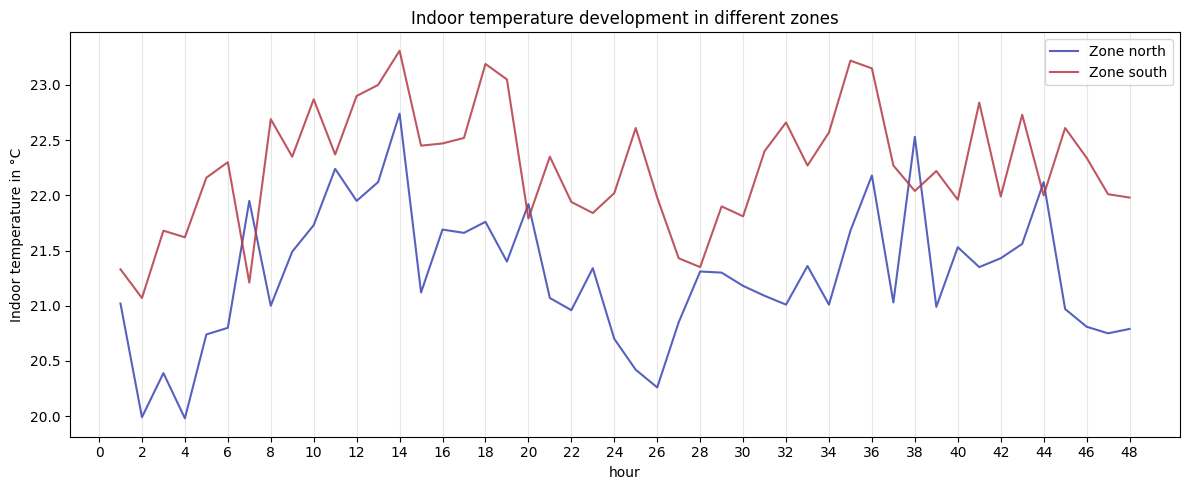

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
for zone, color in [("north", "#3946B3"), ("south", "#B33945")]:
    part = building[building["zone"] == zone]
    ax.plot(
        part["hour"],
        part["indoor_temp_c"],
        color = color,
        label=f"Zone {zone}",
        alpha=0.85
    )
ax.set_xlabel("hour")
ax.set_xticks(range(0, 49, 2))
ax.grid(True, axis="x", alpha=0.3)
ax.set_ylabel("Indoor temperature in °C")
ax.set_title("Indoor temperature development in different zones")
ax.legend()
plt.tight_layout()
plt.show()

##### Findings
The x-axis is a sequential count of hours over a span of two days (48 hours).

The y-axis represents indoor temperature measured in degrees celsius.

The two lines represent the two zones in the building, the northern zone in a blue color and the southern zone in a red color.

In regards to the overall time pattern both zones show indoor temperature following a repeating pattern across the 48-hours. We see two dips in temperature (around hour 2-4 and hour 26-28) and two peaks (around hour 14 and 35-38) per zone. This suggests a cyclical pattern each 24 hours, which matches the two days the data spans, and makes physical sense for an indoor temperature.

The southern zone, over the span of the 48 hours, runs generally warmer than the northern zone, which is consistent with the ~1°C higher average found in 2a. The two lines roughly fall and rise together, suggesting an underlying variable affecting both zones similarly.

Two exceptions stand out around hour 6-7 and again around hour 37-38, where the northern zone momentarily becomes the warmer zone. The northern zone's temperature rises quickly while the southern zone dips. These are short localized deviations and are worth noting as unusual.
<br>



### c. Create a scatterplot of `outdoor_temp_c` against `energy_kwh`, using colour or separate panels for the zones. Describe the direction, form, strength, and unusual points visible in the association.

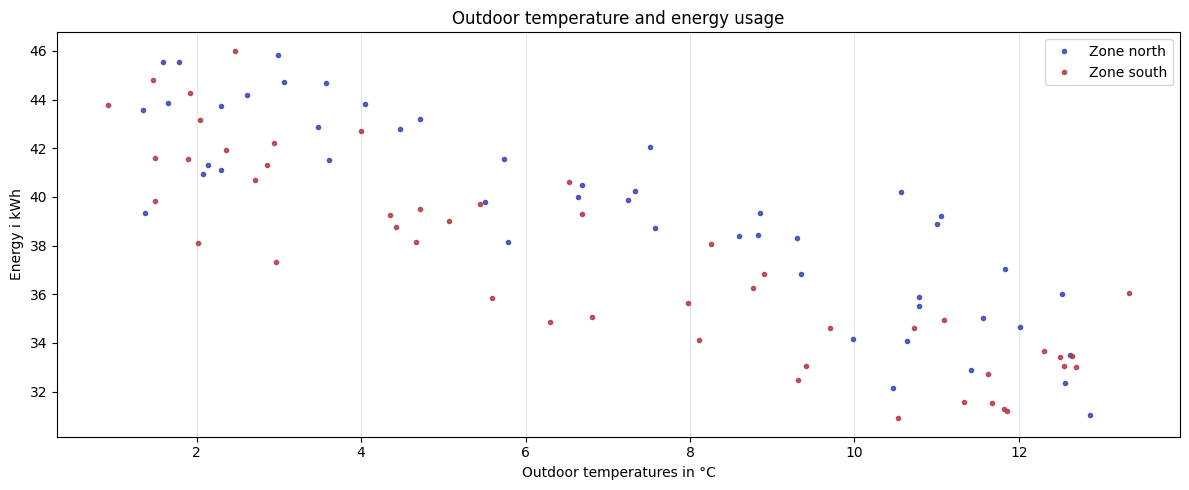

In [ ]:
# Katrine
fig, ax = plt.subplots(figsize=(12, 5))
for zone, color in [("north", "#3946B3"), ("south", "#B33945")]:
    part = building[building["zone"] == zone]
    ax.plot(
        part["outdoor_temp_c"],
        part["energy_kwh"],
        ".",
        color = color,
        label=f"Zone {zone}",
        alpha=0.85
    )
ax.set_xlabel("Outdoor temperatures in °C")
ax.grid(True, axis="x", alpha=0.3)
ax.set_ylabel("Energy in kWh")
ax.set_title("Outdoor temperature and energy usage")
ax.legend()
plt.tight_layout()
plt.show()

#### Findings
What we can see in this scatter plot is a declining linear line, where the lower the temperature outside, the higher the energy usage. It can also be observed that the northern zone (blue dots) tends to sit a bit higher, though there is considerable overlap between the zones.

The points show a moderate to strong negative association, which is what is observed when the two variables move in different directions, when outdoor_temp_c rises, the energy_kwh drops. While the downward trend is clearly visible, energy usage still varies by roughly 6-8 kWh at any given outdoor temperature, out of a total range of about 15 kWh. This could indicate that temperature alone doesn't fully determine energy use.

No unusual points are observed, while there is a variation in spread - points are generally contained within the "cloud", and no samples are differing from the pattern observed.





### d. Write a short conclusion about temperature stability, differences between zones, and the visible energy–temperature relationship. Do not calculate correlation, fit a regression model, or make causal claims at this stage.

```
# Katrine
```

Despite the indoor temperature following a repeating daily cycle, which matches with the two days data span, the indoor temperature stays within a fairly narrow band in both zones, with a standard deviation of only about 0.6°C.

The southern and northern zone has a modest difference in indoor temperature, with the southern zone running a bit warmer, consistent with the approximately 1°C higher average found in 2a. The southern zone also has a tendency to use slightly less energy, where the northern zone, which runs a bit cooler, tends to use slightly more. The scatterplot in 2c shows a similar pattern from a different angle: a visible downward relationship between outdoor temperature and energy consumption, where energy use tends to be higher when outdoor temperatures are lower. Together the observations describe two zones that are individually stable, but modestly different from each other, and an energy/temperature pattern that is visible in this sample, but not something this descriptive analysis can explain.
<br>



<br><br><br><br><br>
## Part 3: Cybersecurity alert system
A security system monitors authentication attempts. Let $M$ denote a malicious attempt and $A$ denote an alert. Historical validation gives:

$$
P(M) = 0.006, \qquad P(A \mid M) = 0.97, \qquad P(A \mid M^c) = 0.015.
$$

Treat these values as model probabilities. For a natural-frequency interpretation, consider 100,000 authentication attempts, for which the expected counts can be treated as whole numbers.

Complete the following tasks:

### a. Define the four elementary outcomes formed from $M$, $M^c$, $A$, and $A^c$. Explain why they are mutually exclusive and exhaustive.

```
#Kristian
```

The probability of a malicious attempt is defined at $P(M) = 0.006$. This is an indicator for how often an authentication attempt is malicious, which is set at 0.06% of the time.<br>
The probability of an alert given a malicious attempt is defined at $P(A | M) = 0.97$. This is an indicator for how often a malicious authentication attempt results in an alert (True Positive) - which happens 97% of the time, here.<br>
The probability of an alert given a non-malicious attempt is defined at $P(A | M^c) = 0.015$. This indicates how often a normal (non-malicious) authentication attempt results in an alert (False Positive).

#### The four potential outcomes:

|       |                                      $A$                                       |                                       $A^c$                                       |
|:-----:|:------------------------------------------------------------------------------:|:---------------------------------------------------------------------------------:|
|  $M$  |   True Positive<br/>Authentication was malicious<br/>and alert was produced    |  False Negative<br/>Authentication was malicious<br/>and alert was NOT produced   |
| $M^c$ | False Positive<br/>Authentication was NOT malicious<br/>and alert was produced | True Negative<br/>Authentication was NOT malicious<br/>and alert was NOT produced |

#### Mutual exclusivity
All four outcomes are mutually exclusive, since each instance of $M$ and $A$ pr. authentication attempt each can only be either true or false.

Mathematically this can be expressed as having 2 different elements which each can assume 2 different values:<br>
$2^2$ = 4 possible unique outcomes.

Logically this is expressed in the table above. A malicious authentication attempt cannot produce both an alert and not produce an alert on the same attempt. It's either, or - not both.
Same thing for the alerts. Either the alerts were triggered on a malicious authentication attempt, or triggered on a normal attempt... An alert cannot both be triggered and not be triggered on the same authentication attempt.


#### Exhaustiveness
As indicated about, there are only 4 potential unique outcomes formed from $M$, $M^c$, $A$, and $A^c$. Either one is false and another is true (2 outcomes), or both are true (1 outcome) or both are false (1 outcome). There exists no more outcome for this, for each authentication attempt.


<br><br>
### b.  Construct a labelled $2 \times 2$ table of expected counts for 100,000 attempts, including row and column totals.

From the provided probabilities, we know the frequency of alerts given malicious attempts pr. 100,000 authentication request as follows:

|        |      $A$       |      $A^c$       |      Totals      |
|:------:|:--------------:|:----------------:|:----------------:|
|  $M$   |      $?$       |       $?$        |  $100,000*P(M)$  |
| $M^c$  |      $?$       |       $?$        | $100,000*P(M^c)$ |
| Totals | $100,000*P(A)$ | $100,000*P(A^c)$ |     100,000      |

As we can see, there are some outcomes we are missing the probabilities for.

First we must determine what $P(M)$, $P(M^c)$, $P(A)$ & $P(A^c)$ are.

$P(M)$ = $0.006$ (Given above)

$P(M^c)$ = $1 - P(M)$ = $1 - 0.006$ = $0.994$ (Complements rule)

In order to determine P(A), we need to use the **Law of total probability**, which states that:

$P(A)$ = $P(A | B) * P(B) + P(A | B^c) * P(B^c)$

Rewritten to our terms, this becomes:

$P(A)$ = $P(A | M) * P(M) + P(A | M^c) * P(M^c)$

We already know both $P(M)$, $P(A | M)$, $P(A | M^c)$ & $P(M^c)$, so we simply substitute and insert these known values to calculate $P(A)$:

$P(A)$ = $0.97 * 0.006 + 0.015 * 0.994$ = $0.02073$

and use the complements rule to get $P(A^c)$:

$P(A^c)$ = $1 - P(A)$ = $1 - 0,02073$ = $0.97927$ (Complements rule)

Knowing this, we can now calculate the totals:

|        |           $A$           |          $A^c$           |         Totals         |
|:------:|:-----------------------:|:------------------------:|:----------------------:|
|  $M$   |            ?            |            ?             |  $100,000*0.006=600$   |
| $M^c$  |            ?            |            ?             | $100,000*0.994=99,400$ |
| Totals | $100,000*0.02073=2,073$ | $100,000*0.97927=97,927$ |        100,000         |

---

With the totals locked in, we now just need to calculate the frequencies of each outcome.

To get the remaining values we need to calculate $M \land A$, $M \land A^c$, $M^c \land A^c$ & $M^c \land A$, such that:

|        |           $A$           |           $A^c$           |  Totals  |
|:------:|:-----------------------:|:-------------------------:|:--------:|
|  $M$   |  $100,000*(A \land M)$  |  $100,000*(A^c \land M)$  |  $600$   |
| $M^c$  | $100,000*(A \land M^c)$ | $100,000*(A^c \land M^c)$ | $99,400$ |
| Totals |         $2,073$         |         $97,927$          | 100,000  |

From the **Law of Total Probability** we know that $P(A \land B) = P(B)*P(A|B)$, and we can use this since we already know that $P(A | M) = 0.97$ & $P(A | M^c) = 0.015$

$P(A \land M) = P(M)*P(A|M)$

$P(A \land M) = 0.006*0.97 = 0.00582$

and

$P(A \land M^c) = P(M^c)*P(A|M^c)$

$P(A \land M^c) = 0.994*0.015 = 0.01491$

Knowing that each row and column must produce the total amounts, we can now populate our table with the missing probable authentication counts dispersion:

|        |           $A$           |         $A^c$         |  Totals   |
|:------:|:-----------------------:|:---------------------:|:---------:|
|  $M$   |  $100,000*0.00582=582$  |     $600-582=18$      |   $600$   |
| $M^c$  | $100,000*0.01491=1,491$ | $99,400-1,491=97,909$ | $99,400$  |
| Totals |         $2,073$         |       $97,927$        | $100,000$ |

---

And thus we end up with this cleaned up 2 x 2 table of the probable counts of each outcome based on 100,000 authentication events:

|        |   $A$   |  $A^c$   |  Totals   |
|:------:|:-------:|:--------:|:---------:|
|  $M$   |  $582$  |   $18$   |   $600$   |
| $M^c$  | $1,491$ | $97,909$ | $99,400$  |
| Totals | $2,073$ | $97,927$ | $100,000$ |


<br><br>
### c. Use the probability model and verify the results from the table:
- $P(M \cap A)$;
- $P(A)$ using the law of total probability;
- $P(M \cup A)$;
- $P(M \mid A)$; and
- $P(M^c \mid A)$.

```
#Kristian
```


#### Verifying $P(M \cap A)$:
This was already calculated in 3b, but here is a basic recap.<br>
Since $P(M \cap A)$ basically means the outcomes where M and A both are true (true positives), we can say that $P(M \cap A) = P(A \cap M)$ since the order of terms does not matter. From the **Law of Total Probability** we know that $P(A \cap B) = P(B)*P(A|B)$, and we can use this since we already know that $P(A | M) = 0.97$

$P(A \cap M) = P(M)*P(A|M) = P(M \cap A)$

$P(A \cap M) = 0.006*0.97 = 0.00582 = P(M \cap A)$

Frequency of M \cap A = 100,000 * 0.00582 = 582 outcomes.

This matches what is displayed in the table

<br>

#### Verifying $P(A)$ using the law of total probability:
This was already calculated in 3b, but here is a recap.<br>

The **Law of total probability**, states that:

$P(A)$ = $P(A | M) * P(M) + P(A | M^c) * P(M^c)$

We already know that $P(M) = 0.006$, $P(A | M) = 0.97$, $P(A | M^c) = 0.015$ & $P(M^c) = 1 - P(M) = 1 - 0.006 = 0.994$:

$P(A)$ = $0.97 * 0.006 + 0.015 * 0.994$ = $0.02073$

Frequency of M \cap A = 100,000 * 0.02073 = 2073 total outcomes of A.

This matches what is displayed in the table

<br>

#### Verifying $P(M \cup A)$:

The **Addition Rule** from the **Rules of Probability** states that $P(A \cup M) = P(A) + P(M) - P(A \cap M)$.

Above we found that $P(A)=0.02073$ & $P(A \cap M)=0.00582$ and we are given that $P(M)=0.006$:

$P(A \cup M) = 0.02073 + 0.006 - 0.00582 = 0.02091$

Frequency of M \cap A = 100,000 * 0.02091 = 2091 total outcomes

$P(M \cup A)$ is the union of events M and A where either is true. (I.e. M or A). This maps to the reported table values $582 + 1,491 + 18 = 2,091$, thus matching what is expected.


<br>

#### Verifying $P(M \mid A)$:
For this, we need to use Bayer's Theorem which states that $P(M | A) = P(A | M) * P(M) / P(A)$.

We have previously identified that $P(A | M)=0.97$ and $P(M)=0.006)$ and $P(A)=0.02073$:

$P(M | A) = 0.97 * 0.006 / 0.02073 = 0.2808$

$P(M \mid A)$ is the probability that a malicious authentication attempt is conditional on an alert (i.e. it was flagged in an alert).

Using the table, we can arrive at the same probability by taking $582$ (positive alerts with positive malicious attempts) $/ 2,073$ (total alerts) $= 0.2808$, thus matching what is expected.

<br>

#### Verifying $P(M^c \mid A)$:

For this, we use the **Complement Rule** from the **Rules of Conditional Probability**, which states that $P(M^c | A) = 1 - P(M | A)$.

We previously identified that $P(M | A) = 0.2808$:

$P(M^c | A) = 1 - 0.2808 = 0.7192$

Using the table, we can arrive at the same probability by taking $1,491$ (positive alerts with negative malicious attempts) $/ 2,073$ (total alerts) $= 0.7192$, thus matching what is expected.

<br><br>
### d. Explain the difference between $P(A \mid M)$ and $P(M \mid A)$. Determine whether $M$ and $A$ are independent and whether they are mutually exclusive, justifying both answers numerically.


```
#Katrine
```

#### Differences between $P(A | M)$ and $P(M | A)$

The difference between the two conditions is determined by the direction of the condition. The two might seem similar but is asking about two different things:
The way we read it: $P(A | M)$ is "probability of A, given M" or $P(M | A)$ is "probability of M, given A".

$P(A | M )$ is saying: given that a malicious attempt has happened, what are the probability that the alarm goes off?
We are also given the solution to $P(A | M) = 0.97$. Which means that if there is a malicious attempt, it is almost always detected


$P(M | A )$ is saying: given an alarm goes off, what are the chances that it is a malicious attempt?
The solution to this is provided to us by 3c: $P(M | A) = 0.97 * 0.006 / 0.02073 = 0.2808$, which means that when the alarm goes off it is only a malicious attempt 28% of the times.


#### Is M and A mutually exclusive?
When determining whether two events are mutually exclusive, we look at whether they can occur at the same time - can a malicious attempt and an alarm going off, happen simultaneously?

We know that the Empty set rule is given by $P(∅) = 0$, the probability of an empty set is 0.
To determine this we examine whether or not the two events have anything in common, if there are disjoint(no outcomes in common) it means that their joint set is empty: $M \cap A = ∅$. Now if we combine these two together: then if $M$ and $A$ are disjoint/mutually exclusive, then $M \cap A$ is the empty set, and the Empty set rule says that the probability of an empty set is always 0. Therefore $P(M \cap A) = 0$.

From 3c we know that:
$P(A \cap M) = 0.006*0.97 = 0.00582 = P(M \cap A)$.

Since $0.00582 ≠ 0$, M and A are not mutually exclusive - they in fact overlap quite a bit, which is the point of a detection system.


#### Is M and A independent?
As stated in the Probability for Data analysis, two events are said to be independent if the probability that one occurs is not affected by, and does not affect, whether the other event occurs or has occured. $P(A | M) = P(A)$

$P(A | M) = 0.97$ and $P(A) = 0.02073$ (from 3b)

$0.97 ≠ 0.02073$, telling us that they are not independent.

This makes sense in the context of a detection system, where whether the alarm goes off is strongly influenced by whether the attempts was actually malicious. If M and A were independent, the alarm would go off independently of an atack, which would mean the systems detects nothing at all.

<br><br>
### e. Suppose an improved system reduces $P(A \mid M^c)$ to 0.005 while leaving the other inputs unchanged. Recalculate $P(M \mid A)$, compare it with the original value, and explain why both the false-positive rate and the base rate matter.

```
#Katrine
```

For this, we need to use Bayer's Theorem which states that $P(M | A) = P(A | M) * P(M) / P(A)$, to calculate $P(M|A)$ with the reduced $P(A|M^c)$
We then compare the old $P(M | A)$ with the newly calculated result.


In [24]:
p_mal = 0.006
p_alarm_given_mal = 0.97
p_alarm_given_nonMal = 0.015
p_alarm_given_nonMal_reduced = 0.005

# Calculation P(M|A) using Bayer's Theroem
def calculate_p_mal_given_alarm(p_m, p_a_given_m, p_a_given_mc):
    # calculating P(M^c) using the complement rule: P(M^c) = 1 - P(M)
    p_mc = 1 - p_m

    # calculation P(A) using the Law of total probability: P(A) = P(A n M) + P(A n M^c)
    p_a = p_a_given_m * p_m + p_a_given_mc * p_mc

    # calculating: P(M|A) = P(A|M) * P(M)/P(A)
    return p_a_given_m * (p_m / p_a)

p_mal_given_alarm_original = calculate_p_mal_given_alarm(p_mal, p_alarm_given_mal, p_alarm_given_nonMal)
p_mal_given_alarm_new = calculate_p_mal_given_alarm(p_mal, p_alarm_given_mal, p_alarm_given_nonMal_reduced)

comparison = pd.DataFrame({
    "P(A | M^c)": [
        p_alarm_given_nonMal,
        p_alarm_given_nonMal_reduced,
        p_alarm_given_nonMal_reduced - p_alarm_given_nonMal,
    ],
    "P(M | A)": [
        p_mal_given_alarm_original,
        p_mal_given_alarm_new,
        p_mal_given_alarm_new - p_mal_given_alarm_original,
    ],
}, index=["Original system", "Improved system", "Change"])

display(comparison.style.set_caption("Effect of reducing the false-positive rate on P(M | A)").format("{:.4f}"))

,P(A | M^c),P(M | A)
Original system,0.0150,0.2808
Improved system,0.0050,0.5394
Change,-0.0100,0.2586


#### Findings
By reducing our false-positive rate by a third(from 0.015 to 0.005), $P(M|A) improves substantially. However, this alone is not enough to make the alarm fully reliable, because the base rate P(M) is very low to begin with: 0.006. So even a very good detection system, with a high detection rate and low error rate, can still be wrong most of the time when the alarm goes off, if what it is looking for is rare enough to begin with.

For $M$ we still have 600 malicious attempts and 582 alarms
For $M^c$: we have 99.400 attempts, $99400*0.005 = 497$ false-positive alarms (down from 1.491)
The total number of alarms is: $582 + 497 = 1079$. Here of is $582 / 1079 = 0.5394$ (53,94%) are actual malicious attempts.

This is a significant improvement from 28% to 54%, but still just over 50%. Even with a third fewer false-positives, we still have 497 false alarms up against 582 real alarms, because the 99.400 attempts are so much larger than the 600 actual malicious attempts. Our base rate in unchanged, which sets a boundary for how close $P(M|A)$ can acutally get to a 100%, no matter how much we improve our false-positive rate.


<br><br><br><br><br>
## Part 4: AI-Use and Conclusion
### AI-use
Briefly state:
- which AI tool or tools you used;
- what you used them for;
- what you changed or rejected; and
- how you checked that the final work was correct.
-
A short paragraph or table is sufficient. If AI produced most of the code or text, say so honestly. Complete chat transcripts are not required. If you did not use AI, state that explicitly.

#### In part 1 Claude Opus 5 was used, its usage involved:
- Assisting with markdown syntax and python syntax.
- Answering questions and giving examples such as:
    - How do I rename a column in a pandas table in python? Give me an example.
    - How do I remove all values from a dataset that does not fit within a specific column value? Give me an example.
    - Give me a python example of a boxplot plot.
    - What does ddof mean? (In relation to understanding the n-1 vs n factor in standard deviation computations)
    - etc.
- To provide feedback on the manually written findings, explanations and descriptions provided to the various sub-parts and conclusion.

##### What changed/got rejected:
- LLM input gave me some more perspective on me not having answered the question relating to spread clearly enough. Based on that highlight, I could re-read my section and re-formulate the text to more clearly highlight how spread relates to each service
- Fixed some typos

##### How I checked that the final work was correct:
- For the statistical analysis, the csv file was imported into excel and using excel tools the counts, frequencies and statistics computed by pandas could be compared against what I could extract and see in the raw data.
- For the plots, I compared these with the raw data, the statistics and the other plots to ensure consistency between these.
- For the outliers I could calculate the upper and lower fences based on the IQR, and independently verify the computationally identified outliers against the raw .csv (excel imported).
- Any LLM output was assessed critically against Richards GitHub tutorial for lesson 1, as well as the contents in the course books chapter 1.
<br><br>

#### In part 2 Claude Sonnet 5 was used, its usage involved:
- Explanation of statistical concepts
- Debugging in Python code
- Reviewing and critiquing the text for the interpretation of the various findings, as well as helping with correct wording
- Help with matplotlib formatting (e.g. how to add x-axis markings and gridlines)

##### What changed/got rejected:
- Adjusting a misinterpretation (counting error of highs/lows) of the cyclical pattern in 2b.
- I rewrote and improved text based on the criticism and wording suggestions from reviewing

##### How I checked that the final work was correct:
- Ran the code and inspected the actual output
- Went over the assignment questions several times
- Went over the plots again to verify that the new counts where right/ensure my interpretation didn't leave anything out
<br><br>

#### Part 3
- In part 3a - 3c AI was not used
- Part 3d and 3e, Claude Sonnet 5 was used to explain statistical concepts, creating the output formatting for 3e and reviewing and critiquing text.


_____________

### Overall conclusion
Write a conclusion of approximately 150–250 words. Summarise the principal finding from each engineering case and explain the difference between describing observed data and reasoning from an assumed probability model. State one limitation of each analysis.

Only use methods introduced in Sessions 1–2. Do not use probability distributions, confidence intervals, hypothesis tests, correlations, regression, or other methods from later sessions.


```
#Part 1: Kristian
```
In part 1, a descriptive analysis of observed latencies in 3 digital service was performed. Identity was the fastest (median 93.7ms), telemetry intermediate (106.9ms) and orders the slowest (114.5ms), all right skewed. Then outliers were identified under the IQR x 1.5 rule, and a principal learning is that outliers more heavily affect the mean and std compared to the median and IQR.
Limitation: The descriptive analysis can only be applied to the given sample (144 observations). With no information about data collection, observation window. It is therefore not possible to use the identified information to explain, or determine, causality in the services that the sample belongs to.

```
#Part 2: Katrine
```
In part 2, indoor temperature followed a 24-hour cycle within a narrow band (std. approx. 0.6°C), with the south zone about 1°C warmer. Energy showed a negative association with outdoor temperature. These patterns were directly observed in the 96 measurements, a limitation however is that only two days from one building were sampled.

```
Part 3a-c: Kristian
```
Part 3 involved using an assumed probability model to reason about outcome of 100,000 authentication attempts in a cybersecurity system. The principle learning was that the probability of A given M outcome does not automatically imply that the probability of M given A is the inverse. Instead, we found that while $P(A | M)$ was 97% that $P(M | A)$ was 28.1%.
Limitation: Since this approach uses an assumed probability model, the model assumptions must apply exactly in the concrete system for these probabilities to be useful in real-world conditions.

```
#Part 3d-e: Katrine
```
In part 3d and 3e, given probabilities were combined using probability rules, showing that M and A were neither mutually exclusive or independent. The low base rate meant $P(M|A)=0.2808$ despite a 97% detection, but when reducing the false-positive rate to 0.005 it raised $P(M|A)$ to 0.5394, but the unchanged base rate still limited the results, thus demonstrating the false-positive paradox. A limitation is that the given probabilites are treated as known rather than estimated from real data.


## Submission checklist (DELETE THIS MARKDOWN FIELD BEFORE HANDIN)
- [ ] Both datasets have been imported and analysed.
- [ ] Every requested table and plot is followed by an interpretation.
- [ ] Sample standard deviations use n-1.
- [ ] Potential outliers are identified but not automatically removed.
- [ ] The probability solution shows events, rules, substitutions, and calculations.
- [ ] Independence and mutual exclusivity are distinguished.
- [ ] Part 4 includes the AI-use statement and conclusion.
- [ ] All code cells have been executed in order and their output is visible.